# <히스토그램 평활화>

## 기본 라이브러리 불러오기

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## 사용자 파라미터(parameter) 정의하기


In [31]:
bit = 8
L = 2**bit
num_bin = L

## toy example 이미지 생성하기(f)

In [32]:
# f = np.array([[2,4,4,3],[2,1,3,3],[1,0,1,2],[0,1,1,2]])
f = cv2.imread("/workspaces/2026-2_Base_Env/computer_vision/cv_2026_docker/images/images/Lenna.png",0)
h,w = f.shape
N = h*w

## 히스토그램 평활화 변환 수행하기

### (1단계) f에 대한 히스토그램 생성하기

In [33]:
hist_f = np.zeros(num_bin)
for x in range (0,h):
    for y in range(0,w):
        hist_f[f[x,y]] += 1

# print(hist_f)

### (2단계) 히스토그램에 대한 누적분포함수 생성하기(cdf_f)

In [34]:
cdf_f = np.cumsum(hist_f)/N
# print(cdf_f)

### (3단계) 맵 생성하기(map_f)

In [35]:
map_f = np.round(cdf_f * (L-1)).astype("uint8")
# print(map_f)

### (4단계) 반복문을 이용하여 mapping 하기(g)

In [36]:
g = np.zeros((h,w))

for x in range(h):
    for y in range(w):
        g[x,y] = map_f[f[x,y]]
g = np.uint8(g)
# print(g)

## 결과 이미지(g)에 대한 히스토그램 생성하기(hist_g)

In [37]:
hist_g = np.zeros(num_bin)
for x in range (0,h):
    for y in range(0,w):
        hist_g[g[x,y]] += 1

# print(g)

## matplotlib.pyplot을 이용하여 결과 히스토그램을 출력하기

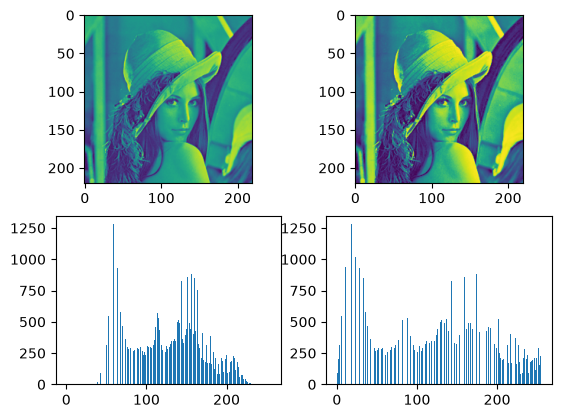

In [40]:
plt.subplot(2,2,1), plt.imshow(f)
plt.subplot(2,2,2), plt.imshow(g)
plt.subplot(2,2,3), plt.bar(np.arange(0,L),hist_f)
plt.subplot(2,2,4), plt.bar(np.arange(0,L),hist_g)
plt.show()